# Case-03：無側移單跨剛架 (No-Sway Single-Bay Frame)

本版直接從 GitHub 抓取最新的 `sd_framework.py` / `samples/model_no_sway_frame.py`，不在 notebook 裡內嵌原始碼。

## 題目摘要
| 項目 | 內容 |
|---|---|
| 結構 | 門型剛架，A、D兩柱底固定，柱高H相同，梁BC承受UDL |
| H | 4.0 m |
| L | 6.0 m |
| w | 24.0 kN/m |
| Dk (獨立位移自由度) | 2 (θ_B, θ_C，無側移Δ) |

## 畫圖規則（拉力彎矩圖）
偏移方向 = 沿桿件「近端→遠端」前進方向逆時針轉90度，正值往這個方向偏移——凸起的那一側就是實際受拉的那一側，已用 anastruct 實際畫圖座標精確驗證。

## 0. 安裝套件 + 抓取最新原始碼

In [1]:
try:
    import anastruct
    print("已偵測到 anastruct，略過安裝")
except ImportError:
    print("未偵測到 anastruct，開始安裝...")
    !pip install anastruct -q --break-system-packages
    try:
        import anastruct
        print("安裝完成，可以繼續往下執行")
    except ImportError:
        print("安裝後仍無法載入，這是 Colab 偶爾會發生的快取問題，"
              "請直接重新執行這個 cell 一次（通常第二次就會成功）")

%matplotlib inline

已偵測到 anastruct，略過安裝


In [2]:
!wget -q -O sd_framework.py https://raw.githubusercontent.com/zhixiu0223/slope_deflection_framework/main/sd_framework.py
!wget -q -O model_no_sway_frame.py https://raw.githubusercontent.com/zhixiu0223/slope_deflection_framework/main/samples/model_no_sway_frame.py

from sd_framework import SlopeDeflectionSolver, member_shear_curve, member_moment_curve, member_offset_curve
from model_no_sway_frame import NoSwayFrameProblem
print("原始碼抓取完成")

原始碼抓取完成


## 1. 求解並產生「手寫詳解」風格輸出（步驟1~7）


【步驟 1】題目定義、幾何/材料參數與自由度標示


**① 結構定義、幾何與邊界條件**

**柱高** $H=4.0$ m (兩柱等高)，**梁跨** $L=6.0$ m，**梁上均佈載重** $w=24.0$ kN/m

**邊界條件：** A、D兩端固定 ($\theta_A=\theta_D=0$)，結構與載重左右對稱、無水平力，所以不側移 ($\psi=0$，沒有 $\Delta$ 這個未知量)

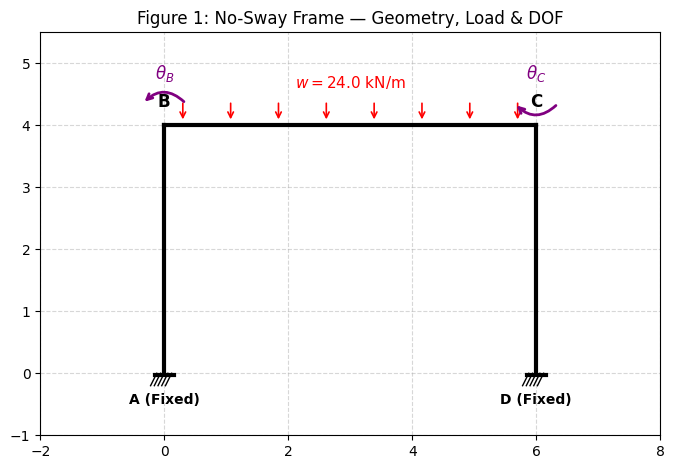

**② ⚠️ 自由度選取**（這一步選錯或漏掉，後面所有方程式都會建立在錯誤基礎上、整題全錯，是最需要覆核的一步）：

A、D固定端轉角鎖死，不是未知量。B、C是梁柱交會的剛性節點，各自有一個轉角 $\theta_B, \theta_C$——這是本課程第一次在同一個節點同時連接柱跟梁(垂直桿件+水平桿件)，節點力矩平衡要把兩種桿件的彎矩式加在一起。因為結構對稱、只有垂直載重、沒有水平力，所以**沒有側移**，不需要像Case-04那樣多列一個 $\Delta$ 自由度跟剪力平衡方程式——這點如果誤判(以為有側移)，會多出一個不存在的自由度跟不必要的剪力平衡方程式。共兩個未知位移量 $\theta_B, \theta_C$。


【步驟 2】寫出桿端彎矩方程式


**① 公式引用**（傾角變位法一般式，對任何桿件 i→j 都適用，跟結構種類無關）：

$$M_{ij} = \frac{2EI}{L}\left(2\theta_i + \theta_j - 3\psi\right) + FEM_{ij}$$

其中 $\theta_i,\theta_j$ 為兩端轉角，$\psi=\Delta/L$ 為側移角（無側移時 $\psi=0$），$FEM_{ij}$ 為固定端彎矩(依載重種類查表)。

**② 代入本題的邊界條件、跨長與載重**，得到每根桿件的具體算式：


【步驟 3】建立平衡方程式


**平衡方程式**（每條方程式對應哪個節點/桿件、哪一種平衡條件）：

- 節點 B 力矩平衡 ΣM_B=0（柱AB與梁BC交會） M_BA + M_BC = 0

- 節點 C 力矩平衡 ΣM_C=0（梁BC與柱CD交會） M_CB + M_CD = 0


【步驟 4】求解聯立方程式 (未知位移量)


**位移求解結果：**


【步驟 5】計算真實桿端彎矩與反力


**最終桿端彎矩計算結果 (kN·m)：**

M_{AB} = -27.000 kN·m
M_{BA} = -54.000 kN·m
M_{BC} = 54.000 kN·m
M_{CB} = -54.000 kN·m
M_{CD} = 54.000 kN·m
M_{DC} = 27.000 kN·m

-> H_A (kN) = -20.250
-> H_D (kN) = 20.250
-> V_A (kN) = 72.000
-> V_D (kN) = 72.000

【步驟 6】繪製剪力圖 (SFD)


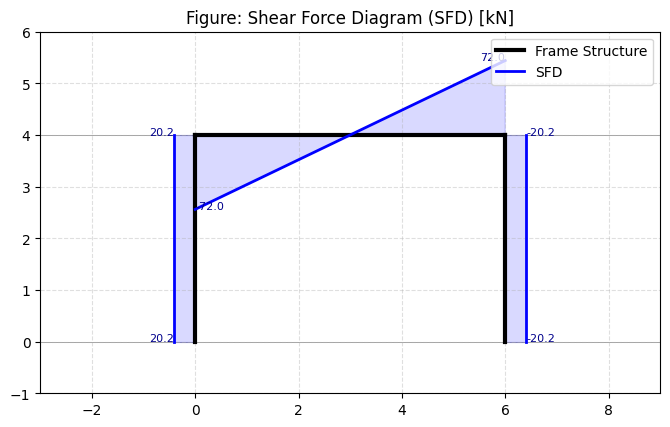


【步驟 7】繪製彎矩圖 (BMD)


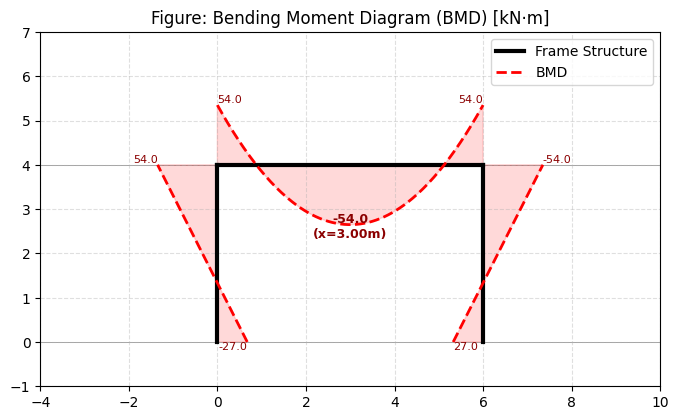

{'moments': {'M_{AB}': -27.0,
  'M_{BA}': -54.0,
  'M_{BC}': 54.0,
  'M_{CB}': -54.0,
  'M_{CD}': 54.0,
  'M_{DC}': 27.0},
 'reactions': {'H_A (kN)': -20.25,
  'H_D (kN)': 20.25,
  'V_A (kN)': 72.0,
  'V_D (kN)': 72.0},
 'solution': {theta_B: -54.0/EI, theta_C: 54.0/EI}}

In [3]:
problem = NoSwayFrameProblem(H=4.0, L=6.0, w=24.0)
solver = SlopeDeflectionSolver(problem)
solver.solve_and_report()

## 1b. 教學講義輸出（含拉力側標註圖）

## 1. 結構受力圖與自由度

**柱高** $H=4.0$ m (兩柱等高)，**梁跨** $L=6.0$ m，**梁上均佈載重** $w=24.0$ kN/m

**邊界條件：** A、D兩端固定 ($\theta_A=\theta_D=0$)，結構與載重左右對稱、無水平力，所以不側移 ($\psi=0$，沒有 $\Delta$ 這個未知量)

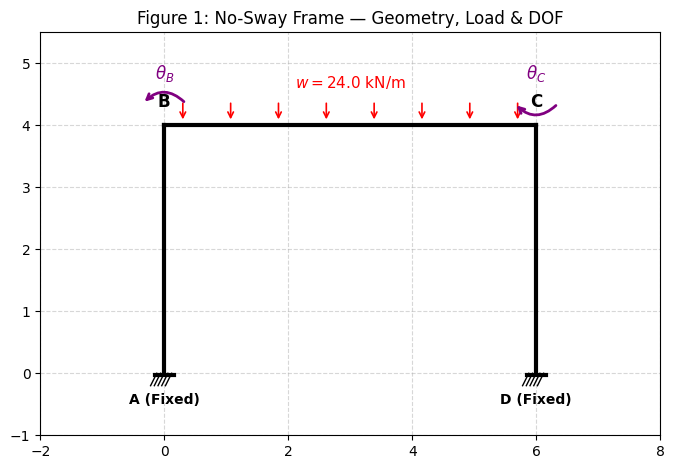

**⚠️ 自由度選取**（這一步選錯或漏掉，後面所有方程式都會建立在錯誤基礎上、整題全錯，是最需要覆核的一步）：

A、D固定端轉角鎖死，不是未知量。B、C是梁柱交會的剛性節點，各自有一個轉角 $\theta_B, \theta_C$——這是本課程第一次在同一個節點同時連接柱跟梁(垂直桿件+水平桿件)，節點力矩平衡要把兩種桿件的彎矩式加在一起。因為結構對稱、只有垂直載重、沒有水平力，所以**沒有側移**，不需要像Case-04那樣多列一個 $\Delta$ 自由度跟剪力平衡方程式——這點如果誤判(以為有側移)，會多出一個不存在的自由度跟不必要的剪力平衡方程式。共兩個未知位移量 $\theta_B, \theta_C$。

## 2. 教學詳解與評分要點

(此模型尚未提供教學詳解)


## 3. 剪力圖 (SFD) 與彎矩圖 (BMD)

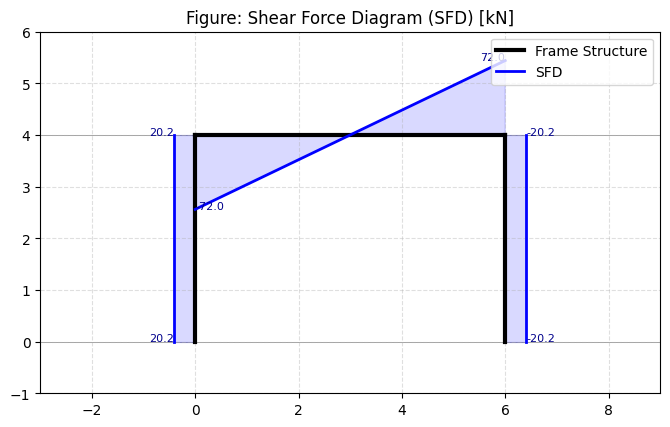

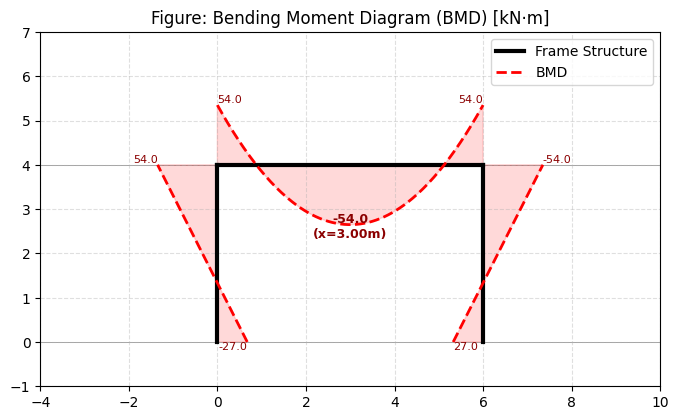

## 4. 拉力彎矩圖對照（受拉/受壓側標註）

上面第3點的彎矩圖本身就是「拉力彎矩圖」——圖形凸起的那一側就是實際受拉的那一側，已用最單純無爭議的案例(懸臂梁)驗證過anastruct 本身就是這樣畫的，不是我們自己認定的。這裡額外把受拉/受壓標成文字，方便直接核對。

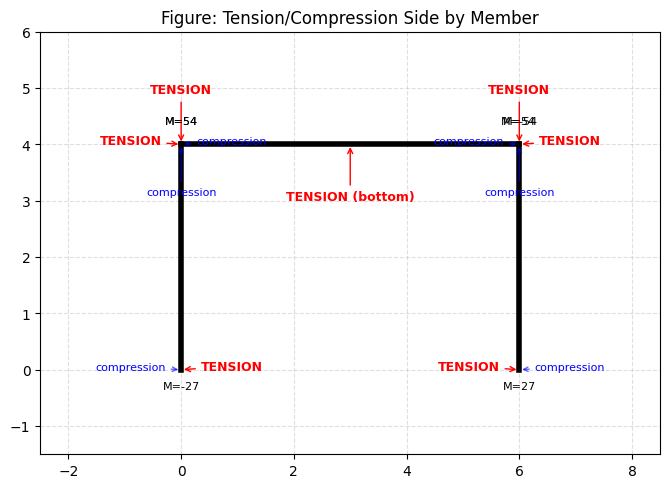

In [4]:
solver.print_teaching_handout()

## 2. anastruct 獨立建模驗證

A反力: {'id': 1, 'Fx': np.float64(-20.249242393205776), 'Fy': np.float64(-72.0), 'Tz': np.float64(26.997850837723075), 'ux': np.float64(-0.0), 'uy': np.float64(0.0), 'phi_z': np.float64(-0.0)}
D反力: {'id': 4, 'Fx': np.float64(20.249242393205755), 'Fy': np.float64(-72.00000000000001), 'Tz': np.float64(-26.99785083772308), 'ux': np.float64(-0.0), 'uy': np.float64(0.0), 'phi_z': np.float64(-0.0)}


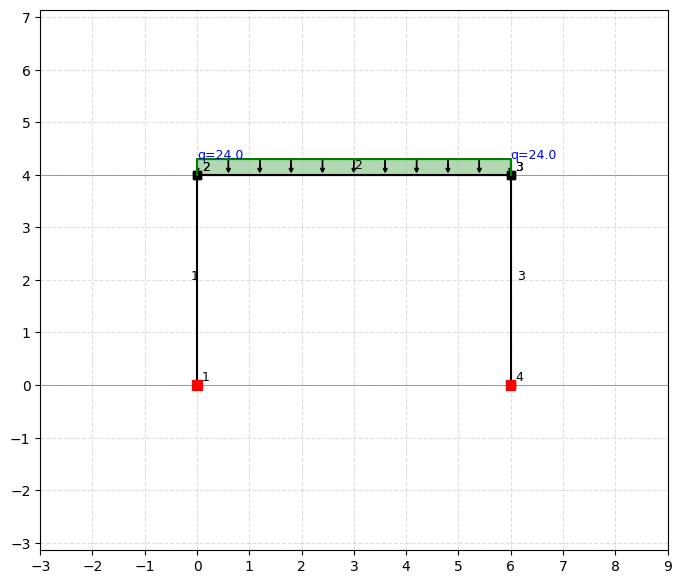

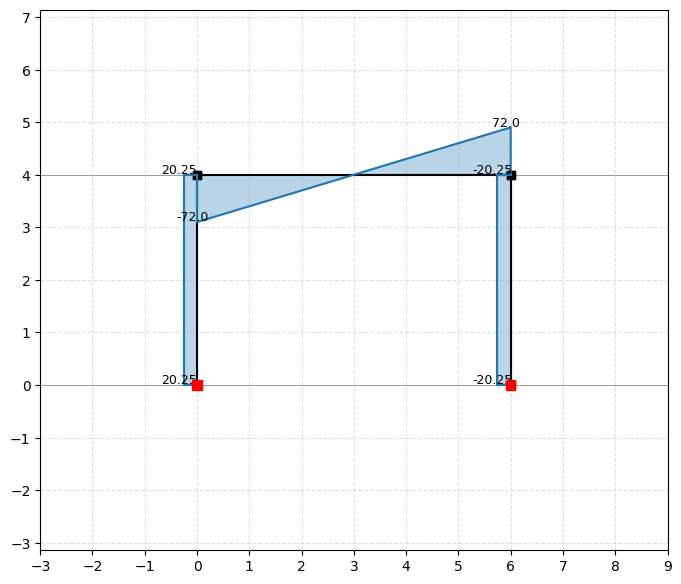

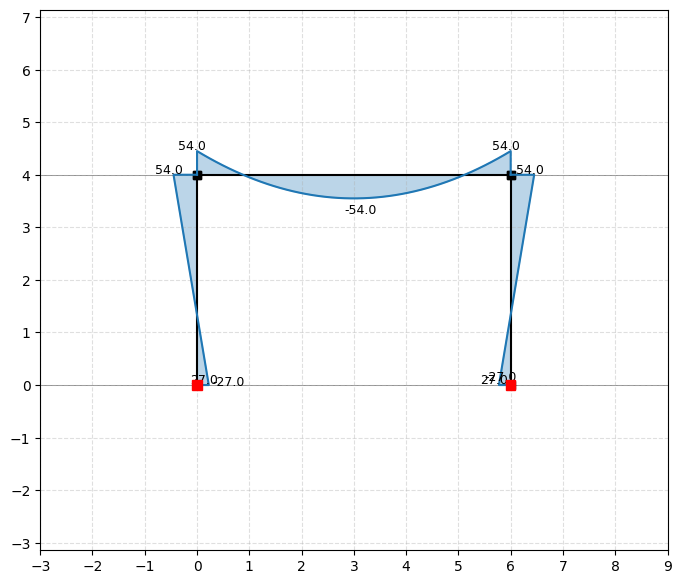

In [5]:
from anastruct import SystemElements
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

H, L, w = 4.0, 6.0, 24.0
ss = SystemElements(EA=1e8, EI=15000.0)
ss.add_element(location=[[0, 0], [0, H]])
ss.add_element(location=[[0, H], [L, H]])
ss.add_element(location=[[L, H], [L, 0]])
ss.add_support_fixed(node_id=1)
ss.add_support_fixed(node_id=4)
ss.q_load(element_id=2, q=-w)
ss.solve()

print("A反力:", ss.get_node_results_system(1))
print("D反力:", ss.get_node_results_system(4))

def apply_grid(fig, y_lines=()):
    ax = fig.axes[0]
    ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(mticker.MultipleLocator(1))
    ax.grid(True, linestyle='--', alpha=0.4)
    for y in y_lines:
        ax.axhline(y, color='gray', lw=0.6, zorder=0)
    return fig

fig_s = ss.show_structure(show=False, figsize=(7, 6))
apply_grid(fig_s, [0, H])
plt.show()

fig_v = ss.show_shear_force(show=False, figsize=(7, 6))
apply_grid(fig_v, [0, H])
plt.show()

fig_m = ss.show_bending_moment(show=False, figsize=(7, 6))
apply_grid(fig_m, [0, H])
plt.show()

## 3. 剪力交叉檢查（柱AB、梁BC、柱CD 各自兩端）

In [6]:
m_ab, m_ba = -27.0, -54.0
m_bc, m_cb = 54.0, -54.0
m_cd, m_dc = 54.0, 27.0

V_ab0 = member_shear_curve(0.0, H, 0.0, m_ab, -m_ba)
V_abH = member_shear_curve(H, H, 0.0, m_ab, -m_ba)
V_bc0 = member_shear_curve(0.0, L, w, m_bc, -m_cb)
V_bcL = member_shear_curve(L, L, w, m_bc, -m_cb)
V_cd0 = member_shear_curve(0.0, H, 0.0, m_dc, -m_cd)
V_cdH = member_shear_curve(H, H, 0.0, m_dc, -m_cd)

print(f"我們框架推算剪力: AB(0)={V_ab0:.3f} AB(H)={V_abH:.3f}  "
      f"BC(0)={V_bc0:.3f} BC(L)={V_bcL:.3f}  CD(D)={V_cd0:.3f} CD(C)={V_cdH:.3f}")

el1, el2, el3 = ss.element_map[1], ss.element_map[2], ss.element_map[3]
print(f"anastruct 實際剪力: AB(0)={el1.shear_force[0]:.3f} AB(H)={el1.shear_force[-1]:.3f}  "
      f"BC(0)={el2.shear_force[0]:.3f} BC(L)={el2.shear_force[-1]:.3f}  "
      f"CD(0)={el3.shear_force[0]:.3f} CD(H)={el3.shear_force[-1]:.3f}")

x1, y1 = member_offset_curve(0, 0, 0, H, np.array([0.0, H]),
                              member_moment_curve(np.array([0.0, H]), H, 0.0, m_ab, -m_ba), 0.00833)
print(f"\n柱AB畫圖座標核對: A點({x1[0]:.3f},{y1[0]:.3f}) 應為(0.225,0.000)  "
      f"B點({x1[1]:.3f},{y1[1]:.3f}) 應為(-0.450,4.000)")

assert abs(V_ab0 - el1.shear_force[0]) < 0.5
assert abs(V_abH - el1.shear_force[-1]) < 0.5
assert abs(V_bc0 - el2.shear_force[0]) < 0.5
assert abs(V_bcL - el2.shear_force[-1]) < 0.5
assert abs(V_cd0 - el3.shear_force[0]) < 0.5
assert abs(V_cdH - el3.shear_force[-1]) < 0.5
print("\n剪力交叉檢查通過 ✓ (三根桿件、六個端點全部核對)")

我們框架推算剪力: AB(0)=20.250 AB(H)=20.250  BC(0)=-72.000 BC(L)=72.000  CD(D)=-20.250 CD(C)=-20.250
anastruct 實際剪力: AB(0)=20.249 AB(H)=20.249  BC(0)=-72.000 BC(L)=72.000  CD(0)=-20.249 CD(H)=-20.249

柱AB畫圖座標核對: A點(0.225,0.000) 應為(0.225,0.000)  B點(-0.450,4.000) 應為(-0.450,4.000)

剪力交叉檢查通過 ✓ (三根桿件、六個端點全部核對)
